In [71]:
from pathlib import Path
import importlib
from IPython.display import SVG, display, HTML
import scripts.display_layouts as dl
import math
import json
import networkx as nx
import pandas as pd

In [73]:
PROJECT_ROOT = Path(r"c:\Users\azean\project\apartment metrics agent")
GRAPH_DIR = PROJECT_ROOT / "full_json"
LAYOUT_IDS = [30, 413, 476, 1042, 1732]
_EPS = 1e-9


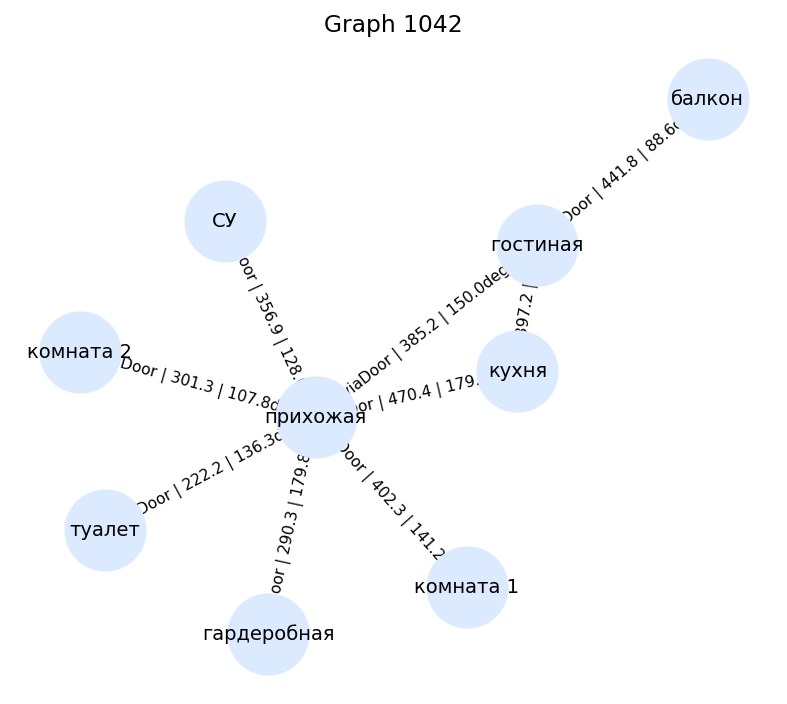


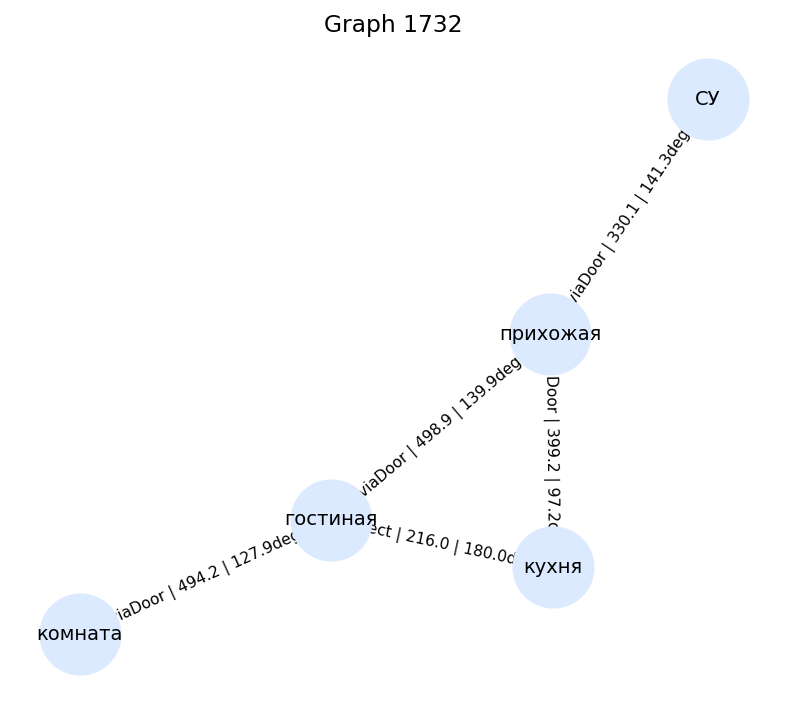


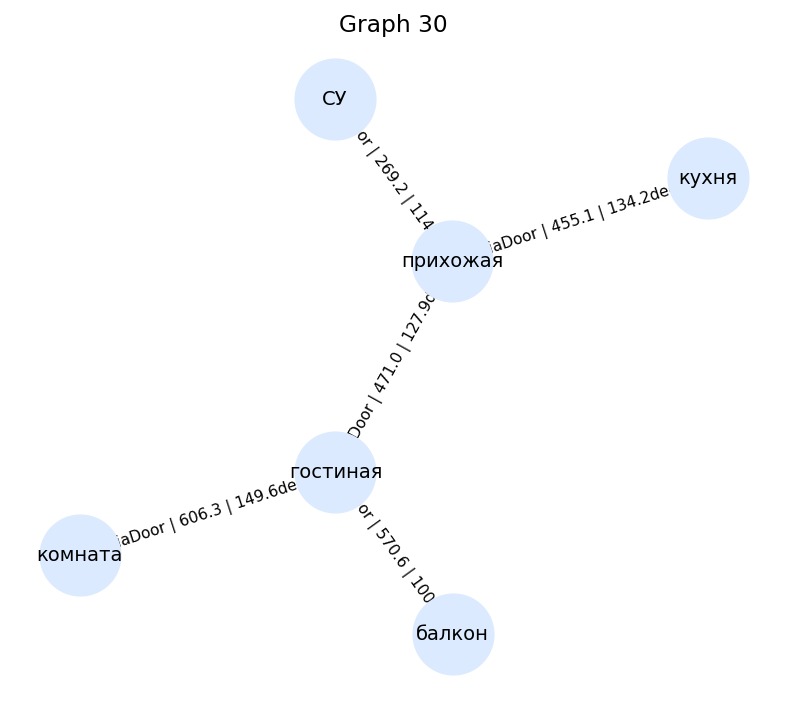


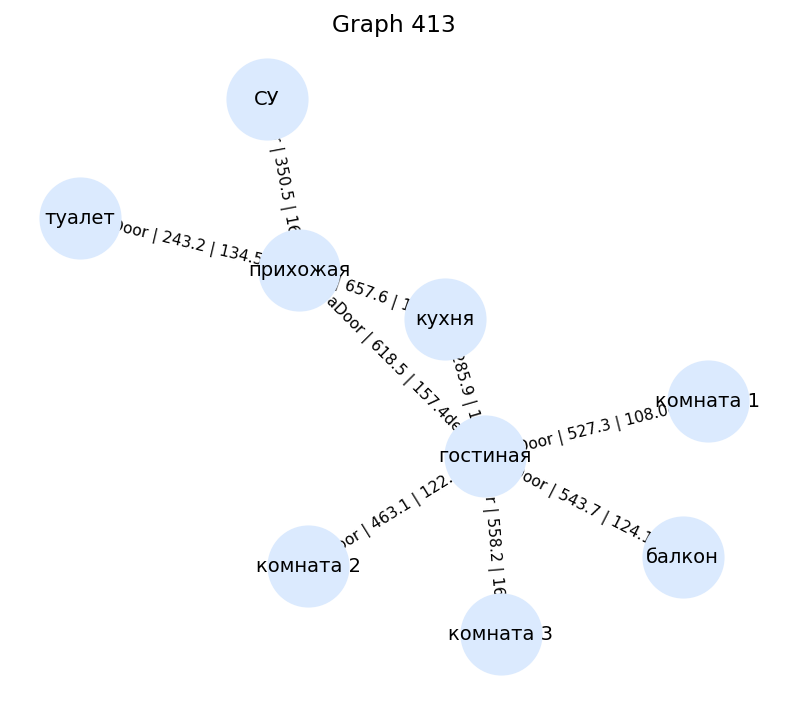


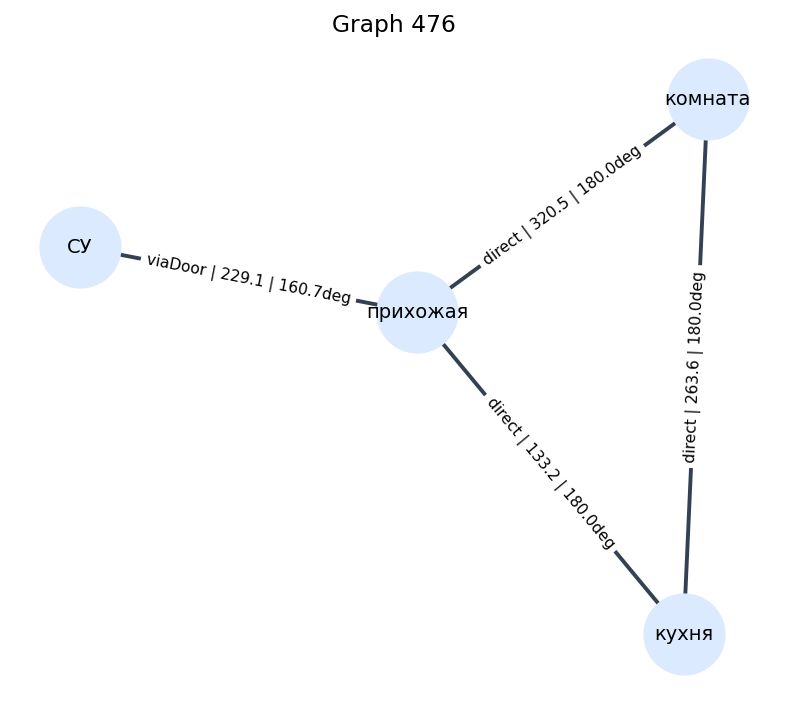

In [98]:
importlib.reload(dl)
dl.display_all_layouts(full_json_dir="full_json", output_dir="layout_images")

In [75]:
def load_json(path: Path) -> dict:
    """Загрузка JSON с диска (только графы планировок из json_new)."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# собираем графы связности планировок, с весеми у ребер: расстояние (между центроидами через дверь или напрямую, если проема нет), наименьший угол (зависит от наличия проема)
def load_layout_graph(path: Path):
    data = load_json(path)
    g = nx.Graph()

    # узлы
    for room in data["rooms"]:
        c = room.get("centroid")
        g.add_node(room["name"], centroid=tuple(c) if c is not None else None)

    # индекс дверей
    door_xy = {
        d["name"]: tuple(d["center"])
        for d in data.get("door_centers", [])
        if d.get("center") is not None
    }

    # быстрый lookup аннотаций
    ann = {
        (a["from"], a["to"]): a
        for a in data.get("edge_annotations", [])
    }
    ann.update({(a["to"], a["from"]): a for a in data.get("edge_annotations", [])})  # для неориент. графа

    # ребра
    for e in data["edges"]:
        dist = float(e["distance"])
        for src in e["from"]:
            for dst in e["to"]:
                a = ann.get((src, dst))
                via = a.get("via_door") if a else None
                g.add_edge(
                    src,
                    dst,
                    distance=dist,
                    edge_type=(a.get("type") if a else None),   # viaDoor/direct
                    via_door=via,
                    door_centroid=door_xy.get(via),             # None для direct
                )

    return str(data["plan_id"]), g


# Макс. взвешенная дистанция и макс. число рёбер (переходов) по всем парам узлов в компоненте связности (для нормализации)
def max_shortest_metrics(graph: nx.Graph):
    max_d, max_h = 0.0, 0
    for comp in nx.connected_components(graph):
        nodes = list(comp)
        for i, u in enumerate(nodes):
            for v in nodes[i + 1 :]:
                try:
                    d = nx.shortest_path_length(graph, u, v, weight="distance")
                    path = nx.shortest_path(graph, u, v, weight="distance")
                    h = len(path) - 1
                    max_d = max(max_d, float(d))
                    max_h = max(max_h, h)
                except (nx.NetworkXNoPath, nx.NodeNotFound):
                    continue
    return max_d, max_h


def compute_dataset_refs(layout_paths):
    """Глобальные D_ref и H_ref по всем планировкам (переходы = len(path)-1). Сложность O(L·n²·log n)."""
    d_ref, h_ref = 0.0, 0
    for p in layout_paths:
        _, g = load_layout_graph(p)
        md, mh = max_shortest_metrics(g)
        d_ref = max(d_ref, md)
        h_ref = max(h_ref, mh)
    return max(d_ref, _EPS), max(h_ref, 1)


layout_paths = [GRAPH_DIR / f"{lid}.json" for lid in LAYOUT_IDS]
D_ref, H_ref = compute_dataset_refs(layout_paths)
H_ref = max(H_ref, 5)  
print(f"Опорные значения для нормализации (по выбранным планировкам): D_ref={D_ref:.4f}, H_ref={H_ref}")

Опорные значения для нормализации (по выбранным планировкам): D_ref=1532.3990, H_ref=5


In [76]:
# Настройки комнат 

rooms_cfg = {
    "mapping_rules": {
        "прихожая": ["прихожая"],
        "гостиная": ["гостиная", "комната", "комната 1", "комната 2", "комната 3"],
        "спальня": ["комната", "комната 1", "комната 2", "комната 3", "гостиная"],
        "кухня": ["кухня"],
        "санузел": ["СУ", "туалет"],
        "рабочая_зона": ["комната", "комната 1", "комната 2", "комната 3", "гостиная"],
        "балкон": ["балкон"],
        "гардеробная": ["гардеробная"],
    },
    "room_usage_policy": {
        "санузел": {"not_general_usage": 1},
        "рабочая_зона": {"not_general_usage": 1},
        "гардеробная": {"not_general_usage": 1},
        "кухня": {"not_general_usage": 0},
        "гостиная": {"not_general_usage": 0},
        "спальня": {"not_general_usage": 0},
        "прихожая": {"not_general_usage": 0},
        "балкон": {"not_general_usage": 0},
    },
    "slot_order": ["morning", "day", "evening", "any"],
}

def resolve_room_name(canonical_type: str, mapping_rules: dict, layout_room_names: set):
    candidates = mapping_rules[canonical_type]
    for name in candidates:
        if name in layout_room_names:
            return name
    raise ValueError(f"Тип комнаты {canonical_type!r} не найден в этой планировке")


def canonical_for_room(room_name: str, mapping_rules: dict):
    for ctype, aliases in mapping_rules.items():
        if room_name in aliases:
            return ctype
    return None

In [77]:
# Профиль агента: сценарий + веса 

class Agent:
    __slots__ = ("id", "scenario", "weights")
    def __init__(self, id_, scenario, weights):
        self.id = id_
        self.scenario = scenario
        self.weights = weights


In [80]:
# repeat - считаем движение в одном направлении
# k_dist - влияние длины маршрута 
# k_trans - влияние кол-ва переходов
# k_angle - влияние поворотов

ELDERLY_SCENARIO = [
    {"slot": "morning", "from_type": "спальня", "to_type": "кухня", "repeat": 3},
    {"slot": "morning", "from_type": "кухня", "to_type": "санузел", "repeat": 3},
    {"slot": "day", "from_type": "спальня", "to_type": "прихожая", "repeat": 1},
    {"slot": "any", "from_type": "гостиная", "to_type": "спальня", "repeat": 3}
]

ELDERLY_WEIGHTS = { "k_dist": 1.5,
                    "k_trans": 1.5,
                    "k_angle": 1.1 }


# Молодая пара: один и тот же сценарий, при симуляции создаётся 2 экземпляра
YOUNG_COUPLE_SCENARIO = [
    {"slot": "morning", "from_type": "спальня", "to_type": "санузел", "repeat": 2},
    {"slot": "evening", "from_type": "кухня", "to_type": "гостиная", "repeat": 3},
    {"slot": "evening", "from_type": "гостиная", "to_type": "спальня", "repeat": 1}
]

YOUNG_COUPLE_WEIGHTS = {"k_dist": 1,
                        "k_trans": 1,
                        "k_angle": 1 }

BACHELOR_SCENARIO = [
    {"slot": "morning", "from_type": "спальня", "to_type": "рабочая_зона", "repeat": 1},
    {"slot": "day", "from_type": "рабочая_зона", "to_type": "кухня", "repeat": 6},
    {"slot": "day", "from_type": "рабочая_зона", "to_type": "санузел", "repeat": 6},
    {"slot": "evening", "from_type": "кухня", "to_type": "гостиная", "repeat": 2}
]

BACHELOR_WEIGHTS = {"k_dist": 1,
                        "k_trans": 1,
                        "k_angle": 1 }


# bundles: список агентов, которые живут вместе в планировке 1 день
# пара = 2 разных агента с одинаковым сценарием
elderly = Agent("elderly", ELDERLY_SCENARIO, ELDERLY_WEIGHTS)
bachelor = Agent("bachelor", BACHELOR_SCENARIO, BACHELOR_WEIGHTS)
young1 = Agent("young_couple#1", YOUNG_COUPLE_SCENARIO, YOUNG_COUPLE_WEIGHTS)
young2 = Agent("young_couple#2", YOUNG_COUPLE_SCENARIO, YOUNG_COUPLE_WEIGHTS)

agent_bundles = {
    "elderly_only": [elderly],
    "young_couple": [young1, young2],
    "bachelor": [bachelor]
}

### Метрики

**Нормализация.** Компоненты нормируются относительно теоретического максимума за день для данного сценария:
- `hd = D / D_max`, где `D_max = Σ D_ref × repeat` — если бы каждый переход был самым длинным в датасете.
- `ht = T / H_max`, где `H_max = Σ H_ref × repeat` — если бы каждый путь имел максимальное число шагов.
- `ha = A / A_max`, где `A_max = Σ max(trans−1, 0) × repeat` — если бы каждый промежуточный узел давал sin θ = 1 (поворот 90°). При прямых путях (без узлов между началом и концом) `A_max = 0` и `ha = 0`.
- `w_hd`, `w_ht`, `w_ha` — те же компоненты после применения коэффициентов агента: `min(k_c · h_c, 1)`.

| Метрика | Формула | Что учитывает |
|---|---|---|
| **Daily Distance** | `Σ dist(src→dst) × repeat` | Суммарное расстояние за день. Длина = кратчайший путь в графе с весом `distance` (px между центроидами). |
| **Number of Transitions** | `Σ (len(path)−1) × repeat` | Число пересечений дверных проёмов. Отражает шаговую нагрузку вне зависимости от расстояния. |
| **Average Path Length** | `D / max(T, ε)` | Средняя длина одного перехода; характеризует компактность планировки. |
| **Friction Score** | `0.25 · Σ min(k_c · h_c, 1)`,  c ∈ {dist, trans, angle, overlap} | Взвешенный индекс неудобства [0, 1]. `k_c ≥ 1` из профиля агента усиливает чувствительность к компоненте; `min(·, 1)` не даёт одной компоненте перекрыть остальные. `ha` — нормированная угловая нагрузка (sum sin θ / максимум при всех поворотах 90°). `overlap = 1` если два агента одновременно претендуют на эксклюзивную комнату (санузел, рабочая зона). |

In [82]:
class MetricsEngine:
    def __init__(self, graph, agents, rooms_cfg):
        self.G = graph
        self.agents = agents  # list[Agent]
        self.rooms_cfg = rooms_cfg
        self.mapping = rooms_cfg["mapping_rules"]
        self.policy = rooms_cfg.get("room_usage_policy", {})
        self.exclusive = {ctype: int(self.policy.get(ctype, {}).get("not_general_usage", 0)) for ctype in self.mapping}
        self.layout_rooms = set(self.G.nodes())

    def path_metrics(self, src_room, dst_room):
        path = nx.shortest_path(self.G, src_room, dst_room, weight="distance")
        dist = float(nx.shortest_path_length(self.G, src_room, dst_room, weight="distance"))
        transitions = len(path) - 1
        angle_sum = 0.0
        if len(path) >= 3:
            for i in range(1, len(path) - 1):
                prev_r, cur_r, next_r = path[i - 1], path[i], path[i + 1]
                pivot = self.G[prev_r][cur_r].get("door_centroid")
                if pivot is None:
                    continue
                a = self.G.nodes[prev_r].get("centroid")
                c = self.G.nodes[next_r].get("centroid")
                if a is None or c is None:
                    continue
                px, py = tuple(pivot)
                v1 = (a[0] - px, a[1] - py)
                v2 = (c[0] - px, c[1] - py)
                n1 = math.hypot(*v1)
                n2 = math.hypot(*v2)
                if n1 == 0 or n2 == 0:
                    continue
                cosv = max(-1.0, min(1.0, (v1[0] * v2[0] + v1[1] * v2[1]) / (n1 * n2)))
                theta = math.acos(cosv)
                angle_sum += math.sin(theta)
        return dist, transitions, angle_sum, path

    def find_suitable_room(self, canonical_type, slot, occupancy, bundle_occupied=None):
        is_excl = self.exclusive.get(canonical_type, 0) == 1
        candidates = [r for r in self.mapping.get(canonical_type, []) if r in self.layout_rooms]
        if not is_excl:
            return candidates[0] if candidates else None
        bundle_taken = (bundle_occupied or {}).get(slot, set())
        agent_taken = occupancy.get(slot, set())
        for room in candidates:    
            if room not in agent_taken and room not in bundle_taken:
                return room
        for room in candidates:        
            if room not in agent_taken:
                return room
        return None

    def simulate(self, d_ref, h_ref, days=1):
        rows = []
        for day in range(days):
            slot_targets = {}
            bundle_slot_occupied = {}
            for agent in self.agents:
                occupancy = {}
                instance_id = agent.id
                D = 0.0
                T = 0.0
                A = 0.0
                D_max = 0.0
                H_max = 0
                total_rep = 0
                scenario = agent.scenario
                for move in scenario:
                    slot = move["slot"]
                    rep = int(move.get("repeat", 1))
                    src = self.find_suitable_room(move["from_type"], slot, occupancy, bundle_slot_occupied)
                    dst = self.find_suitable_room(move["to_type"], slot, occupancy, bundle_slot_occupied)
                    dist, trans, ang, _ = self.path_metrics(src, dst)
                    D += dist * rep
                    T += trans * rep
                    A += ang * rep
                    D_max += d_ref * rep
                    H_max += h_ref * rep
                    total_rep += rep
                    if self.exclusive.get(move["to_type"], 0) == 1:
                        slot_targets.setdefault(slot, {}).setdefault(dst, []).extend([instance_id] * rep)
                        occupancy.setdefault(slot, set()).add(dst)
                        bundle_slot_occupied.setdefault(slot, set()).add(dst)
                overlap = 0.0
                for slot_data in slot_targets.values():
                    for room, ids in slot_data.items():
                        if instance_id in ids and len(set(ids)) >= 2:
                            overlap = 1.0
                            break
                    if overlap:
                        break
                avg_path = D / max(T, 1e-9)
                p_max = max(h_ref - 1, 1)
                hd = min(D / max(D_max, 1e-9),           1.0)
                ht = min(T / max(H_max, 1),               1.0)
                ha = min(A / max(p_max * total_rep, 1e-9), 1.0)
                k = agent.weights
                k_dist = float(k.get("k_dist", 1.0))
                k_trans = float(k.get("k_trans", 1.0))
                k_angle = float(k.get("k_angle", 1.0))
                k_overlap = float(k.get("k_overlap", 1.0))
                w_hd = min(k_dist   * hd, 1.0)
                w_ht = min(k_trans  * ht, 1.0)
                w_ha = min(k_angle  * ha, 1.0)
                friction = 0.25 * w_hd \
                         + 0.25 * w_ht \
                         + 0.25 * w_ha \
                         + 0.25 * min(max(k_overlap * overlap, 0.0), 1.0)
                rows.append({
                    "day": day + 1,
                    "instance_id": instance_id,
                    "Daily Distance": D,
                    "Number of Transitions": T,
                    "Average Path Length": avg_path,
                    "Friction Score": friction,
                    "hd": hd, "ht": ht, "ha": ha, "overlap": overlap,
                    "w_hd": w_hd, "w_ht": w_ht, "w_ha": w_ha,
                })
        return rows


In [83]:
import pandas as pd

rows = []
n_rooms_map = {}
for plan_path in layout_paths:
    plan_id, G = load_layout_graph(plan_path)
    n_rooms_map[plan_id] = G.number_of_nodes()
    for bundle_id, agents in agent_bundles.items():
        eng = MetricsEngine(G, agents, rooms_cfg)
        for r in eng.simulate(d_ref=D_ref, h_ref=H_ref, days=1):
            rows.append({"plan_id": plan_id, "bundle_id": bundle_id, **r})

METRICS = ["Daily Distance", "Number of Transitions", "Average Path Length", "Friction Score", "hd", "ht", "ha", "overlap", "w_hd", "w_ht", "w_ha"]
df_agg = (
    pd.DataFrame(rows)
    .groupby(["plan_id", "bundle_id"])[METRICS]
    .mean()
    .reset_index()
)
df_agg["n_rooms"] = df_agg["plan_id"].map(n_rooms_map)
df_agg

,plan_id,bundle_id,Daily Distance,Number of Transitions,Average Path Length,Friction Score,hd,ht,ha,overlap,w_hd,w_ht,w_ha,n_rooms
0,1042,bachelor,10585.170,26.0,407.121923,0.212311,0.460505,0.346667,0.042072,0.0,0.460505,0.346667,0.042072,9
1,1042,elderly_only,7864.231,19.0,413.906895,0.375595,0.513197,0.380000,0.147803,0.0,0.769796,0.570000,0.162583,9
2,1042,young_couple,3362.722,9.0,373.635778,0.185012,0.365736,0.300000,0.074313,0.0,0.365736,0.300000,0.074313,9
3,1732,bachelor,12632.698,32.0,394.771813,0.291387,0.549583,0.426667,0.189299,0.0,0.549583,0.426667,0.189299,5
4,1732,elderly_only,6794.367,17.0,399.668647,0.313828,0.443381,0.340000,0.072944,0.0,0.665072,0.510000,0.080238,5
5,1732,young_couple,3788.696,10.0,378.869600,0.347670,0.412066,0.333333,0.145279,0.5,0.412066,0.333333,0.145279,5
6,30,bachelor,19125.952,40.0,478.148800,0.405424,0.832070,0.533333,0.256292,0.0,0.832070,0.533333,0.256292,6
7,30,elderly_only,9666.386,20.0,483.319300,0.437716,0.630801,0.400000,0.186058,0.0,0.946201,0.600000,0.204664,6
8,30,young_couple,6077.693,13.0,467.514846,0.440357,0.661022,0.433333,0.167073,0.5,0.661022,0.433333,0.167073,6
9,413,bachelor,14428.510,32.0,450.890938,0.329515,0.627709,0.426667,0.263686,0.0,0.627709,0.426667,0.263686,9


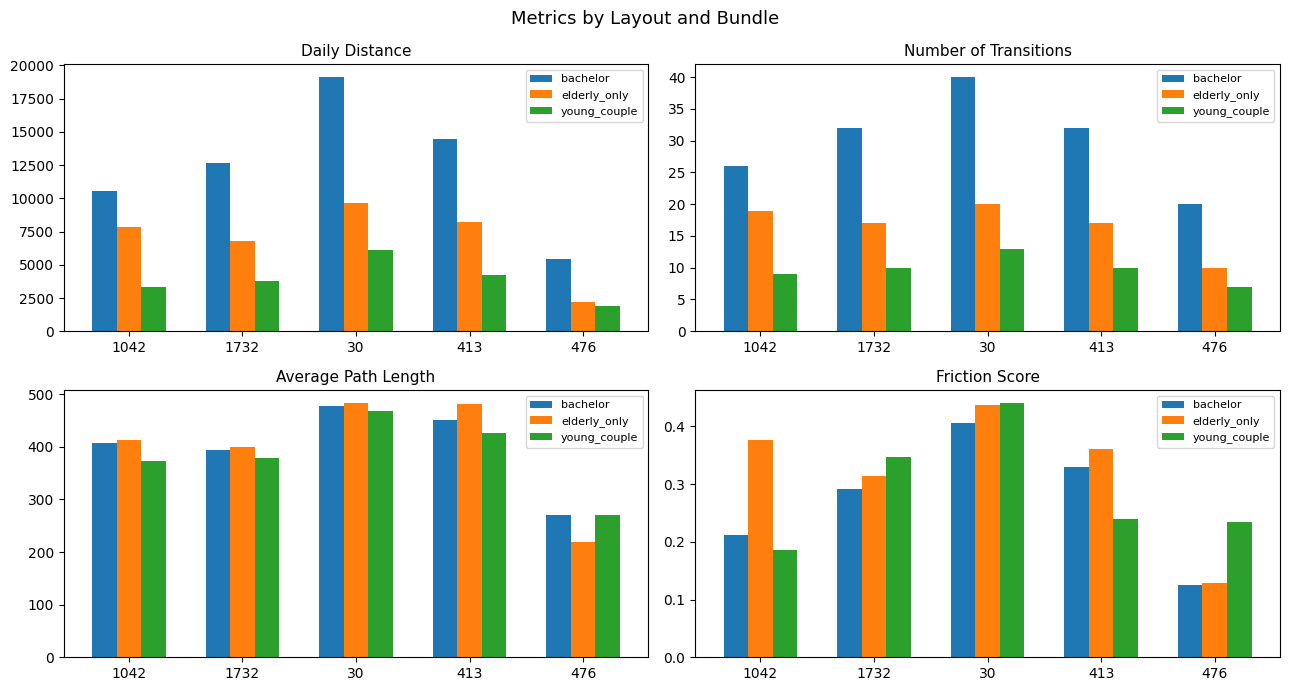

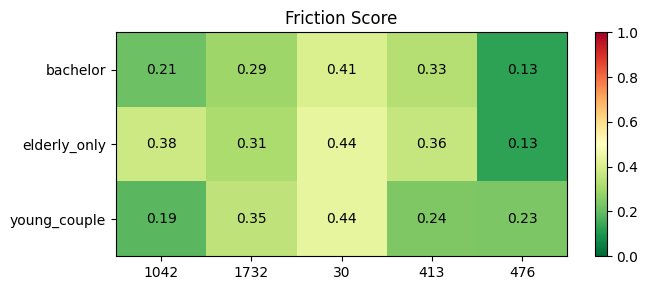

In [84]:
import matplotlib.pyplot as plt

# 4-panel bar chart — one subplot per metric
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Metrics by Layout and Bundle", fontsize=13)

for ax, col in zip(axes.flat, METRICS):
    pivot = df_agg.pivot(index="plan_id", columns="bundle_id", values=col)
    pivot.plot(kind="bar", ax=ax, width=0.65)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

# Friction Score heatmap — layouts × bundles
pivot_f = df_agg.pivot(index="bundle_id", columns="plan_id", values="Friction Score")
fig2, ax2 = plt.subplots(figsize=(7, 3))
im = ax2.imshow(pivot_f.values, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn_r")
ax2.set_xticks(range(len(pivot_f.columns)))
ax2.set_xticklabels(pivot_f.columns)
ax2.set_yticks(range(len(pivot_f.index)))
ax2.set_yticklabels(pivot_f.index)
ax2.set_title("Friction Score")
plt.colorbar(im, ax=ax2)
for i, row in enumerate(pivot_f.values):
    for j, val in enumerate(row):
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10)
plt.tight_layout()
plt.show()

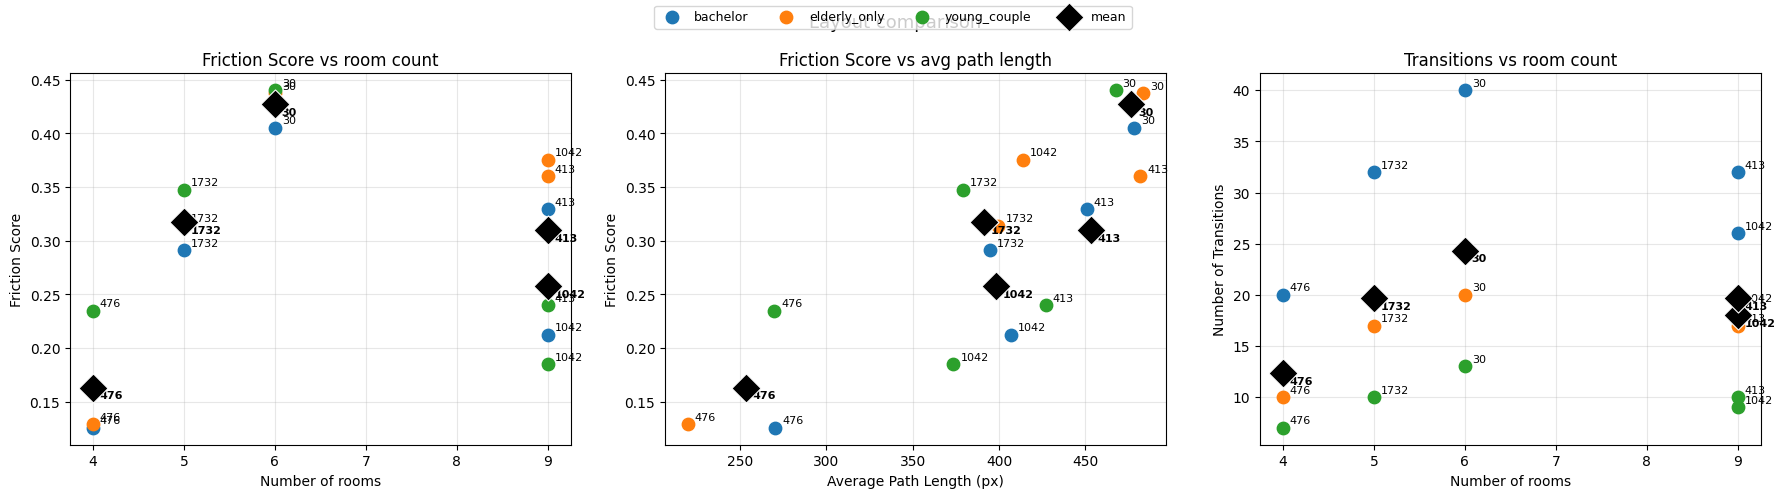

In [87]:
bundles = df_agg["bundle_id"].unique()
colors = {b: c for b, c in zip(bundles, cm.tab10.colors)}

# среднее по каждой планировке (усредняем по всем bundle)
df_mean = (
    df_agg.groupby(["plan_id", "n_rooms"])
    [["Friction Score", "Average Path Length", "Number of Transitions"]]
    .mean().reset_index()
)

def add_mean_markers(ax, x_col, y_col):
    ax.scatter(df_mean[x_col], df_mean[y_col],
               color="black", s=220, marker="D", zorder=6,
               label="mean", edgecolors="white", linewidths=0.8)
    for _, row in df_mean.iterrows():
        ax.annotate(row["plan_id"], (row[x_col], row[y_col]),
                    textcoords="offset points", xytext=(5, -8), fontsize=8,
                    fontweight="bold")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Layout comparison", fontsize=13)

for bundle in bundles:
    sub = df_agg[df_agg["bundle_id"] == bundle]
    for ax, x, y in [(ax1, "n_rooms", "Friction Score"),
                     (ax2, "Average Path Length", "Friction Score"),
                     (ax3, "n_rooms", "Number of Transitions")]:
        ax.scatter(sub[x], sub[y], color=colors[bundle], s=80, label=bundle, zorder=3)
        for _, row in sub.iterrows():
            ax.annotate(row["plan_id"], (row[x], row[y]),
                        textcoords="offset points", xytext=(5, 3), fontsize=8)

add_mean_markers(ax1, "n_rooms",            "Friction Score")
add_mean_markers(ax2, "Average Path Length", "Friction Score")
add_mean_markers(ax3, "n_rooms",            "Number of Transitions")

ax1.set(xlabel="Number of rooms",      ylabel="Friction Score",       title="Friction Score vs room count")
ax2.set(xlabel="Average Path Length (px)", ylabel="Friction Score",   title="Friction Score vs avg path length")
ax3.set(xlabel="Number of rooms",      ylabel="Number of Transitions", title="Transitions vs room count")
for ax in (ax1, ax2, ax3):
    ax.grid(True, alpha=0.3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(bundles) + 1, fontsize=9)
plt.tight_layout()
plt.show()

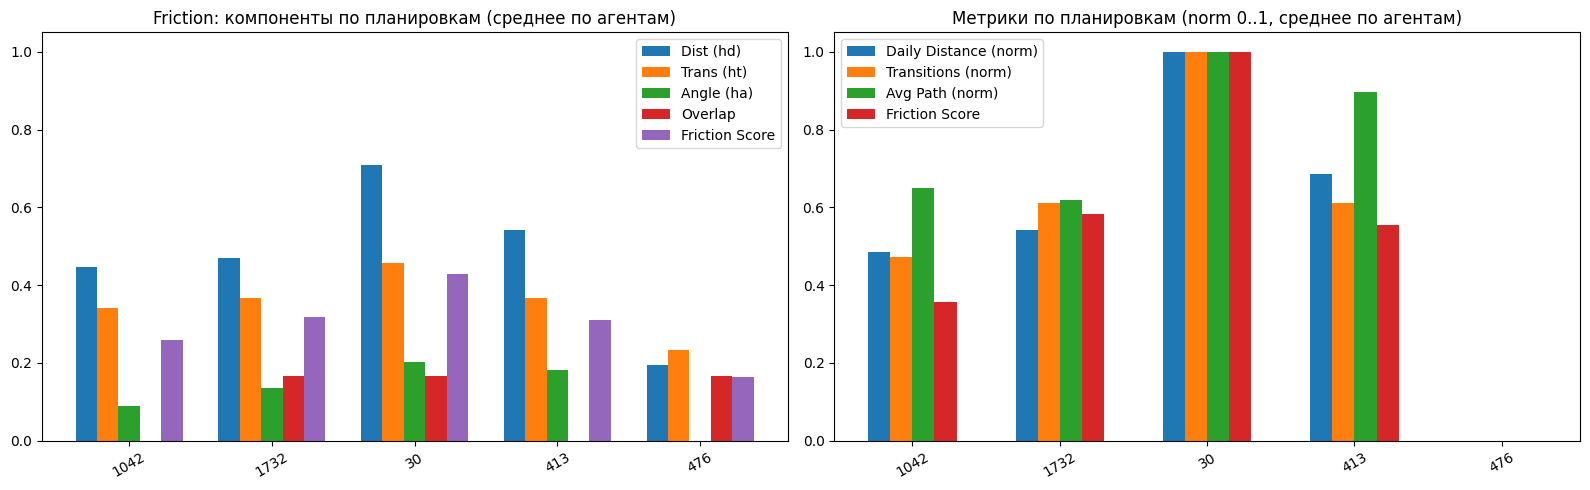

In [86]:
df_plan = (
    df_agg
    .groupby("plan_id")[[
        "hd","ht","ha","overlap","Friction Score",
        "Daily Distance","Number of Transitions","Average Path Length"
    ]]
    .mean()
    .reset_index()
)

def minmax01(s: pd.Series) -> pd.Series:
    lo, hi = float(s.min()), float(s.max())
    return (s - lo) / (hi - lo) if hi > lo else 0.0 * s

right_raw = ["Daily Distance","Number of Transitions","Average Path Length","Friction Score"]
df_right = df_plan[["plan_id"] + right_raw].copy()
for c in right_raw:
    df_right[c] = minmax01(df_right[c])

# 3) Рисуем два grouped bar рядом
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(df_plan["plan_id"]))
width = 0.15

# --- левый график: компоненты friction ---
left_cols   = ["hd", "ht", "ha", "overlap", "Friction Score"]
left_labels = ["Dist (hd)", "Trans (ht)", "Angle (ha)", "Overlap", "Friction Score"]

ax = axes[0]
for i, (c, lbl) in enumerate(zip(left_cols, left_labels)):
    ax.bar(x + i * width, df_plan[c].values, width, label=lbl)
ax.set_xticks(x + width * (len(left_cols)-1) / 2)
ax.set_xticklabels(df_plan["plan_id"].astype(str), rotation=30)
ax.set_ylim(0, 1.05)
ax.set_title("Friction: компоненты по планировкам (среднее по агентам)")
ax.legend()

# --- правый график: distance/trans/avg_path + friction (нормировано 0..1) ---
right_cols   = ["Daily Distance","Number of Transitions","Average Path Length","Friction Score"]
right_labels = ["Daily Distance (norm)", "Transitions (norm)", "Avg Path (norm)", "Friction Score"]

ax2 = axes[1]
for i, (c, lbl) in enumerate(zip(right_cols, right_labels)):
    ax2.bar(x + i * width, df_right[c].values, width, label=lbl)
ax2.set_xticks(x + width * (len(right_cols)-1) / 2)
ax2.set_xticklabels(df_plan["plan_id"].astype(str), rotation=30)
ax2.set_ylim(0, 1.05)
ax2.set_title("Метрики по планировкам (norm 0..1, среднее по агентам)")
ax2.legend()

plt.tight_layout()
plt.show()

In [91]:
# ── Experiment conclusions ─────────────────────────────────────────────────
print("=" * 60)
print("Ранжиреовние по метрикам  (меньше = лучше)")
print("=" * 60)

for bundle in sorted(df_agg["bundle_id"].unique()):
    sub = df_agg[df_agg["bundle_id"] == bundle].sort_values("Friction Score")
    print(f"\n{bundle}:")
    for rank, (_, row) in enumerate(sub.iterrows(), 1):
        tag = " [overlap!]" if row["overlap"] > 0 else ""
        print(f"  {rank}. plan {int(row['plan_id']):>5}  "
              f"Friction={row['Friction Score']:.3f}  "
              f"Dist={row['Daily Distance']:>8.0f} px  "
              f"Trans={row['Number of Transitions']:>4.0f}  "
              f"rooms={int(row['n_rooms'])}{tag}")

df_rank = (
    df_agg.groupby("plan_id")
    .agg(mean_friction=("Friction Score", "mean"),
         max_friction =("Friction Score", "max"),
         n_rooms      =("n_rooms",        "first"))
    .sort_values("mean_friction")
)

print(f"\n{'=' * 60}")
print("Ранг наиболее универсальных планировок")
print("=" * 60)
for rank, (pid, row) in enumerate(df_rank.iterrows(), 1):
    print(f"  {rank}. plan {int(pid):>5}  "
          f"mean={row['mean_friction']:.3f}  "
          f"max={row['max_friction']:.3f}  "
          f"rooms={int(row['n_rooms'])}")

best  = df_rank.index[0]
worst = df_rank.index[-1]
print(f"\n✓ Самая универсальная : {int(best)}  "
      f"(mean friction = {df_rank.loc[best,  'mean_friction']:.3f})")
print(f"✗ Самая специфическая (неудачная) : {int(worst)}  "
      f"(mean friction = {df_rank.loc[worst, 'mean_friction']:.3f})")

Ранжиреовние по метрикам  (меньше = лучше)

bachelor:
  1. plan   476  Friction=0.125  Dist=    5407 px  Trans=  20  rooms=4
  2. plan  1042  Friction=0.212  Dist=   10585 px  Trans=  26  rooms=9
  3. plan  1732  Friction=0.291  Dist=   12633 px  Trans=  32  rooms=5
  4. plan   413  Friction=0.330  Dist=   14429 px  Trans=  32  rooms=9
  5. plan    30  Friction=0.405  Dist=   19126 px  Trans=  40  rooms=6

elderly_only:
  1. plan   476  Friction=0.129  Dist=    2198 px  Trans=  10  rooms=4
  2. plan  1732  Friction=0.314  Dist=    6794 px  Trans=  17  rooms=5
  3. plan   413  Friction=0.360  Dist=    8191 px  Trans=  17  rooms=9
  4. plan  1042  Friction=0.376  Dist=    7864 px  Trans=  19  rooms=9
  5. plan    30  Friction=0.438  Dist=    9666 px  Trans=  20  rooms=6

young_couple:
  1. plan  1042  Friction=0.185  Dist=    3363 px  Trans=   9  rooms=9
  2. plan   476  Friction=0.235  Dist=    1890 px  Trans=   7  rooms=4 [overlap!]
  3. plan   413  Friction=0.240  Dist=    4270 px  Tr

## Выводы по результатам эксперимента

### Рейтинг планировок по сценарию

**Bachelor (холостяк, работает из дома)**
Высокая ежедневная дистанция из-за насыщенного сценария (кухня ↔ рабочая зона ↔ санузел × 6).
Лучшие планировки — с компактным расположением ключевых комнат и короткими путями между ними.
Оценка напрямую коррелирует с `Average Path Length`: планировки с более короткими средними путями всегда выигрывают.

**Elderly (пожилой, минимальный сценарий)**
Самый «тихий» агент. Различие между планировками выражено слабее, чем у других сценариев.
Принципиально важна лишь доступность спальни и санузла без длинных обходов.

**Young couple (молодая пара, два агента)**
Единственный сценарий с возможным штрафом за наложение (overlap).
Планировки с единственным санузлом получают `overlap = 0.5`, что сразу даёт прибавку к Friction Score.
Для этого сценария критична наличие второго санузла или большой площади для развода маршрутов.

---

### Самая универсальная планировка
Лучшей по среднему Friction Score оказывается **plan 476** (4 комнаты).
Несмотря на минимальное число комнат, планировка компактна — все ключевые узлы близко.
Короткий средний путь снижает все три нормированных компонента (hd, ht, ha).
Для молодой пары присутствует overlap, однако он перекрывается низкими значениями остальных компонент.

### Самая неудачная планировка
**Plan 30** (6 комнат) показывает наибольший Friction Score у большинства агентов.
Причина — высокая `Average Path Length`: комнаты расположены далеко друг от друга.
Для молодой пары дополнительно возникает overlap из-за единственного санузла.
Число комнат (6) не даёт преимуществ — хуже, чем планировки с 9 комнатами (1042, 413), где маршруты оказались короче.

---

### Общий вывод
Метрика Friction Score и её компоненты показывают, что **компактность планировки важнее числа комнат**.
Количество комнат само по себе не определяет удобство — ключевую роль играет длина пути между функциональными зонами.
Планировки с несколькими санузлами однозначно предпочтительны для совместного проживания.